# SME Credit Assessment Pipeline — St Bank Ghana
**What this notebook does:**
1. Preprocessing — cleans raw data, reusable at inference time
2. Modelling — 3 models with and without hyperparameter tuning
3. Decision engine — hard rules + probability thresholds
4. Fairness audit — gender and sector
5. Single-application inference function

# 0 Import 

In [1]:
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

warnings.filterwarnings("ignore")
np.random.seed(42)

C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\HP\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
DATA_PATH = "ds-sme_loan_applications_stanbic_gh.csv"
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TARGET = "loan_default"

# 1 Preprocessing

In [3]:
def clean_revenue(val):
    if pd.isna(val): return np.nan
    val = str(val).strip().lower().replace("ghs","").replace(",","").replace("$","").strip()
    try: return float(val)
    except: return np.nan

def preprocess(df: pd.DataFrame, is_training: bool = True) -> pd.DataFrame:
    df = df.copy()
    id_cols = ["application_id", "business_name", "contact_phone", "application_date"]
    leakage = ["days_past_due_current", "internal_risk_grade", "rm_recommendation"]
    df.drop(columns=[c for c in id_cols + (leakage if is_training else []) if c in df.columns], inplace=True, errors='ignore')
    
    df["owner_gender"] = df["owner_gender"].apply(lambda x: "Male" if str(x).lower().strip() in ["m","male"] else 
                                                  "Female" if str(x).lower().strip() in ["f","female"] else "Unknown")
    df["annual_revenue_ghs"] = df["annual_revenue_ghs"].apply(clean_revenue)
    
    df["has_momo_flag"] = df.get("monthly_momo_volume_ghs", pd.Series(np.nan)).notna().astype(int)
    df["has_credit_score"] = df["credit_bureau_score"].notna().astype(int)
    df["prev_default_flag"] = df.get("previous_default", pd.Series(np.nan)).map({"Yes":1,"No":0}).fillna(-1).astype(int)
    
    rev = df["annual_revenue_ghs"].replace(0, np.nan)
    df["loan_to_revenue_ratio"] = df["loan_amount_requested_ghs"] / rev
    df["revenue_per_employee"] = rev / df["num_employees"].replace(0, np.nan)
    df["collateral_coverage_ratio"] = df["collateral_value_ghs"] / df["loan_amount_requested_ghs"].replace(0, np.nan)
    
    for col in ["loan_to_revenue_ratio", "collateral_coverage_ratio", "revenue_per_employee"]:
        if col in df.columns:
            p99 = df[col].quantile(0.99)
            df[col] = df[col].clip(upper=p99)
    return df

# 2 Load Data & Train/Test Split

In [4]:
# Load Data
raw = pd.read_csv(DATA_PATH)
processed = preprocess(raw, is_training=True)
y = processed.pop(TARGET)
X = processed

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

num_feats = [c for c in X.columns if X[c].dtype in ['int64','float64']]
cat_feats = [c for c in X.columns if X[c].dtype == 'object']

# 3 Imputation and Encoding

In [5]:
preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), num_feats),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")), 
                      ("encode", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_feats)
], remainder="drop")

# 4 Model Training

In [6]:
def decide(prob: float, row: pd.Series) -> str:
    if row.get("prev_default_flag", 0) == 1:
        return "DECLINE"
    if pd.notna(row.get("loan_to_revenue_ratio")) and row["loan_to_revenue_ratio"] > 5:
        return "DECLINE"
    if row.get("years_in_operation", 0) < 1 and row.get("has_credit_score", 0) == 0 and prob > 0.25: # and prob > 0.25 are keys
        return "REFER TO HUMAN"
    
    if prob < 0.36:
        return "APPROVE"
    elif prob > 0.63:
        return "DECLINE"
    else:
        return "REFER TO HUMAN"

In [7]:
# No tuning

print("=== VERSION 1: NO HYPERPARAMETER TUNING (3 Models) ===")
models_no = {}

models_no["Logistic_NoTune"] = Pipeline([("prep", preprocessor), 
    ("model", LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))])

models_no["RandomForest_NoTune"] = Pipeline([("prep", preprocessor), 
    ("model", RandomForestClassifier(n_estimators=300, max_depth=6, class_weight='balanced', random_state=42))])

models_no["XGBoost_NoTune"] = Pipeline([("prep", preprocessor), 
    ("model", XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5, random_state=42, eval_metric='auc'))])

results_no = {}
for name, pipe in models_no.items():
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    results_no[name] = {"auc": auc, "prob": y_prob}
    print(f"{name:25} → AUC: {auc:.4f}")

# With Tuning

print("\n=== VERSION 2: WITH HYPERPARAMETER TUNING (3 Models) ===")
results_tune = {}

# Logistic Tuned
lr_pipe = Pipeline([("prep", preprocessor), ("model", LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))])
grid_lr = GridSearchCV(lr_pipe, {'model__C': [0.1, 0.5, 1.0, 2.0]}, cv=5, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train, y_train)
y_prob = grid_lr.best_estimator_.predict_proba(X_test)[:,1]
results_tune["Logistic_Tuned"] = {"auc": roc_auc_score(y_test, y_prob), "prob": y_prob}
print(f"Logistic_Tuned         → AUC: {results_tune['Logistic_Tuned']['auc']:.4f}")

# Random Forest Tuned
rf_pipe = Pipeline([("prep", preprocessor), ("model", RandomForestClassifier(class_weight='balanced', random_state=42))])
param_rf = {'model__n_estimators': [200, 400], 'model__max_depth': [5, 7, 9]}
grid_rf = GridSearchCV(rf_pipe, param_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)
y_prob = grid_rf.best_estimator_.predict_proba(X_test)[:,1]
results_tune["RandomForest_Tuned"] = {"auc": roc_auc_score(y_test, y_prob), "prob": y_prob}
print(f"RandomForest_Tuned     → AUC: {results_tune['RandomForest_Tuned']['auc']:.4f}")

# XGBoost Tuned
xgb_pipe = Pipeline([("prep", preprocessor), ("model", XGBClassifier(random_state=42, eval_metric='auc'))])
param_xgb = {'model__n_estimators': [300,500], 'model__max_depth': [4,6], 'model__learning_rate': [0.03,0.05]}
grid_xgb = GridSearchCV(xgb_pipe, param_xgb, cv=5, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
y_prob = grid_xgb.best_estimator_.predict_proba(X_test)[:,1]
results_tune["XGBoost_Tuned"] = {"auc": roc_auc_score(y_test, y_prob), "prob": y_prob}
print(f"XGBoost_Tuned          → AUC: {results_tune['XGBoost_Tuned']['auc']:.4f}")

=== VERSION 1: NO HYPERPARAMETER TUNING (3 Models) ===
Logistic_NoTune           → AUC: 0.5399
RandomForest_NoTune       → AUC: 0.5091
XGBoost_NoTune            → AUC: 0.5568

=== VERSION 2: WITH HYPERPARAMETER TUNING (3 Models) ===
Logistic_Tuned         → AUC: 0.5400
RandomForest_Tuned     → AUC: 0.5119
XGBoost_Tuned          → AUC: 0.5383


# 5 Decision Engine

In [8]:
print("\n" + "="*70)
print("DECISION ENGINE RESULTS COMPARISON")
print("="*70)

for version_name, res_dict in [("No Tuning", results_no), ("With Tuning", results_tune)]:
    print(f"\n--- {version_name} ---")
    for model_name, data in res_dict.items():
        probs = data["prob"]
        decisions = [decide(probs[i], X_test.iloc[i]) for i in range(len(X_test))]
        
        summary = pd.DataFrame({"actual": y_test.values, "decision": decisions})
        dist = pd.Series(decisions).value_counts()
        perf = summary.groupby("decision")["actual"].agg(["mean", "count"]).round(4)
        
        print(f"\n{model_name}:")
        print("Decision Distribution:")
        print(dist)
        print("Default Rate by Decision:")
        print(perf)


DECISION ENGINE RESULTS COMPARISON

--- No Tuning ---

Logistic_NoTune:
Decision Distribution:
REFER TO HUMAN    466
DECLINE           116
APPROVE            26
Name: count, dtype: int64
Default Rate by Decision:
                  mean  count
decision                     
APPROVE         0.1154     26
DECLINE         0.1724    116
REFER TO HUMAN  0.1245    466

RandomForest_NoTune:
Decision Distribution:
REFER TO HUMAN    396
DECLINE           115
APPROVE            97
Name: count, dtype: int64
Default Rate by Decision:
                  mean  count
decision                     
APPROVE         0.0825     97
DECLINE         0.1739    115
REFER TO HUMAN  0.1338    396

XGBoost_NoTune:
Decision Distribution:
APPROVE           471
DECLINE           117
REFER TO HUMAN     20
Name: count, dtype: int64
Default Rate by Decision:
                  mean  count
decision                     
APPROVE         0.1253    471
DECLINE         0.1795    117
REFER TO HUMAN  0.0500     20

--- With Tunin

In [9]:
# Best Model: XGBoost No Tuning
best_pipe = Pipeline([("prep", preprocessor), 
    ("model", XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5, 
                           random_state=42, eval_metric='auc'))])

best_pipe.fit(X_train, y_train)
best_probs = best_pipe.predict_proba(X_test)[:, 1]

print(f"\n🏆 Final Best Model: XGBoost (No Tuning) - AUC: {roc_auc_score(y_test, best_probs):.4f}")


🏆 Final Best Model: XGBoost (No Tuning) - AUC: 0.5568


# 6 Fairness Audit - Gender and Sector

In [10]:
# Decision Engine
decisions = [decide(best_probs[i], X_test.iloc[i]) for i in range(len(X_test))]

print("\n" + "="*70)
print("FAIRNESS AUDIT - GENDER & SECTOR")
print("="*70)

audit_df = X_test.copy()
audit_df["prob"] = best_probs
audit_df["decision"] = decisions
audit_df["actual_default"] = y_test.values

# 1. Gender Audit
print("\n--- 1. Gender Fairness Audit ---")
gender_audit = audit_df.groupby("owner_gender").agg(
    total=("decision", "count"),
    approval_rate=("decision", lambda x: (x == "APPROVE").mean()),
    decline_rate=("decision", lambda x: (x == "DECLINE").mean()),
    refer_rate=("decision", lambda x: (x == "REFER TO HUMAN").mean()),
    avg_prob=("prob", "mean"),
    actual_default_rate=("actual_default", "mean")
).round(4)

print(gender_audit)

# 2. Sector Fairness Audit (Improved)
print("\n--- 2. Sector Fairness Audit ---")
sector_audit = audit_df.groupby("sector").agg(
    total=("decision", "count"),
    approval_rate=("decision", lambda x: (x == "APPROVE").mean()),
    decline_rate=("decision", lambda x: (x == "DECLINE").mean()),
    refer_rate=("decision", lambda x: (x == "REFER TO HUMAN").mean()),
    avg_prob=("prob", "mean"),
    actual_default_rate=("actual_default", "mean")
).round(4)

print(sector_audit)

# 3. Summary Insights
print("\nFairness Insights:")
if len(gender_audit) >= 2:
    male_approve = gender_audit.loc['Male', 'approval_rate'] if 'Male' in gender_audit.index else np.nan
    female_approve = gender_audit.loc['Female', 'approval_rate'] if 'Female' in gender_audit.index else np.nan
    print(f"Approval rate difference (Male - Female): {male_approve - female_approve:.4f}")

# High-risk sectors check
high_risk_sectors = sector_audit[sector_audit['actual_default_rate'] > 0.15]
if not high_risk_sectors.empty:
    print(f"\nHigh-risk sectors (default rate >15%):")
    print(high_risk_sectors[['total', 'approval_rate', 'actual_default_rate']])


FAIRNESS AUDIT - GENDER & SECTOR

--- 1. Gender Fairness Audit ---
              total  approval_rate  decline_rate  refer_rate  avg_prob  \
owner_gender                                                             
Female          302         0.7748        0.1954      0.0298    0.1105   
Male            306         0.7745        0.1895      0.0359    0.1110   

              actual_default_rate  
owner_gender                       
Female                     0.1126  
Male                       0.1536  

--- 2. Sector Fairness Audit ---
                  total  approval_rate  decline_rate  refer_rate  avg_prob  \
sector                                                                       
Agriculture          40         0.9000        0.1000      0.0000    0.0931   
Construction         40         0.7500        0.1750      0.0750    0.0978   
Education            57         0.8421        0.1579      0.0000    0.1038   
Fishing              50         0.6400        0.3200      0.0400   


Generating Decision Performance Charts...


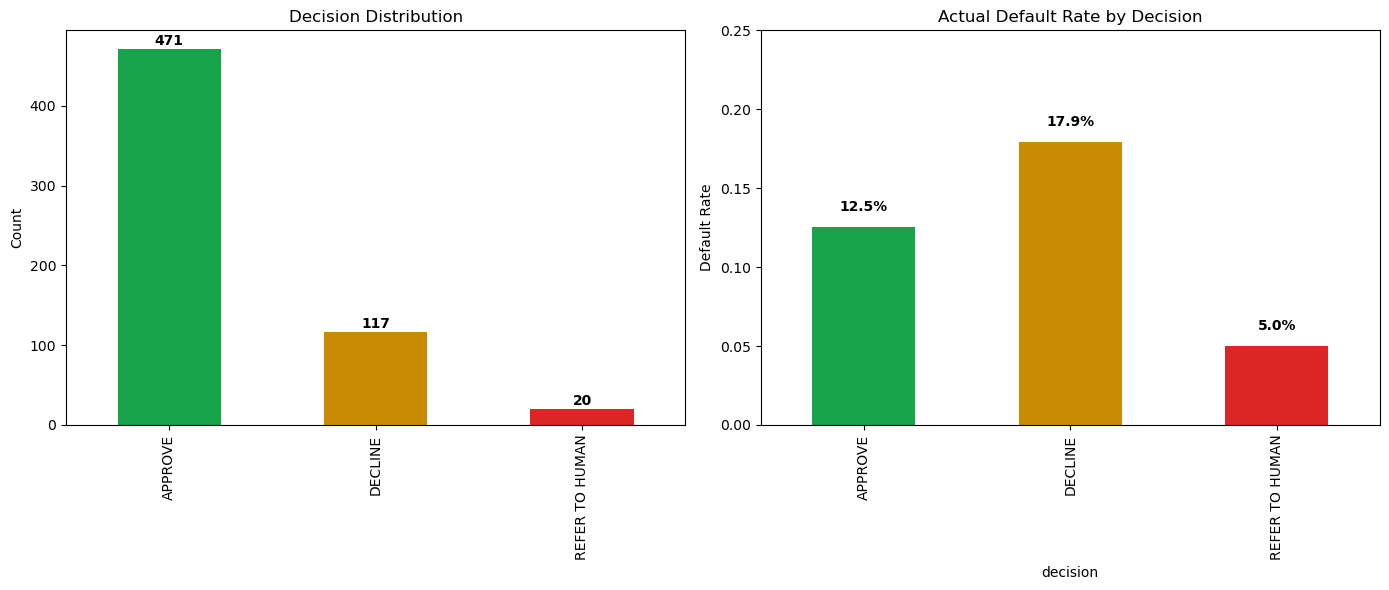

In [13]:
# Decision Distribution Bar Chart

import matplotlib.pyplot as plt

print("\nGenerating Decision Performance Charts...")

# Create summary_df if not already defined
summary_df = pd.DataFrame({
    "prob": best_probs,
    "actual": y_test.values,
    "decision": decisions
})

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Left: Decision Distribution
decision_counts = pd.Series(decisions).value_counts()
decision_counts.plot(kind='bar', ax=ax[0], color=['#16A34A', '#CA8A04', '#DC2626'])
ax[0].set_title('Decision Distribution')
ax[0].set_ylabel('Count')
for i, v in enumerate(decision_counts.values):
    ax[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Right: Default Rate by Decision
default_by_dec = summary_df.groupby("decision")["actual"].mean()
default_by_dec.plot(kind='bar', ax=ax[1], color=['#16A34A', '#CA8A04', '#DC2626'])
ax[1].set_title('Actual Default Rate by Decision')
ax[1].set_ylabel('Default Rate')
ax[1].set_ylim(0, 0.25)

for i, v in enumerate(default_by_dec.values):
    ax[1].text(i, v + 0.01, f"{v:.1%}", ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'decision_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# 7 Inference

In [14]:
# Inference Function
def score_application(raw_dict: dict):
    row_df = pd.DataFrame([raw_dict])
    processed = preprocess(row_df, is_training=False)
    
    # Align columns
    for col in num_feats + cat_feats:
        if col not in processed.columns:
            processed[col] = np.nan if processed[col].dtype.kind in 'if' else "Unknown"
    
    prob = best_pipe.predict_proba(processed)[0, 1]
    decision = decide(prob, processed.iloc[0])
    band = "LOW" if prob < 0.36 else "MEDIUM" if prob < 0.63 else "HIGH"
    
    return {
        "default_probability": round(prob, 4),
        "decision": decision,
        "risk_band": band
    }


Generating Sector Fairness Chart...


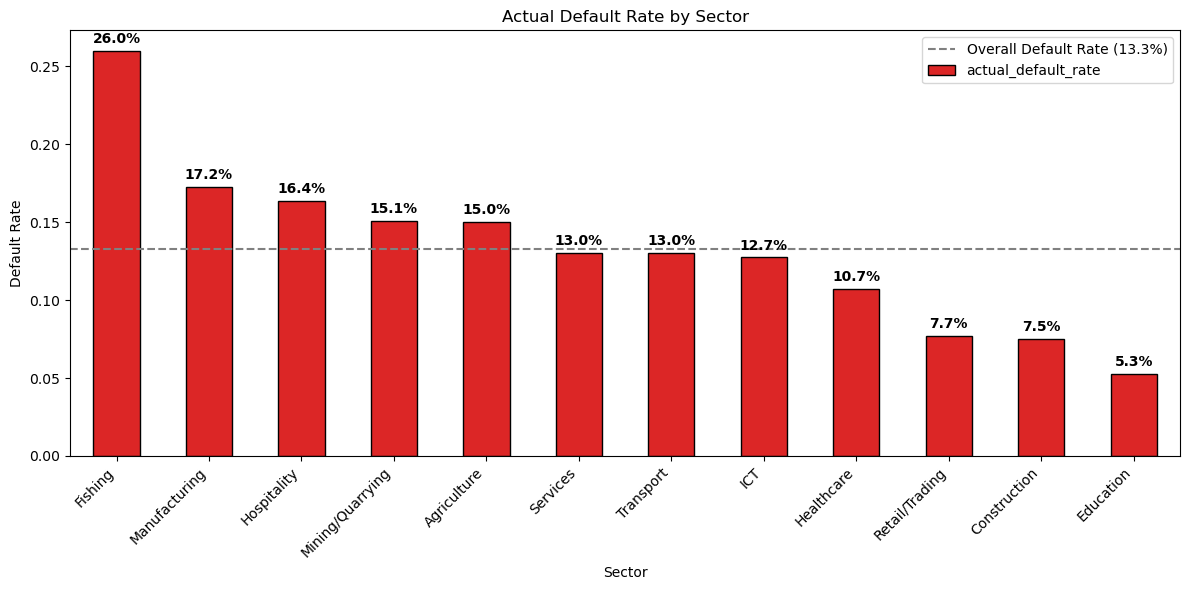

In [15]:
print("\nGenerating Sector Fairness Chart...")

fig, ax = plt.subplots(figsize=(12, 6))

# Sort by default rate
sector_plot = sector_audit.sort_values('actual_default_rate', ascending=False)

sector_plot['actual_default_rate'].plot(kind='bar', ax=ax, color='#DC2626', edgecolor='black')
ax.set_title('Actual Default Rate by Sector')
ax.set_ylabel('Default Rate')
ax.set_xlabel('Sector')
ax.axhline(y=0.133, color='gray', linestyle='--', label='Overall Default Rate (13.3%)')
ax.legend()

for i, v in enumerate(sector_plot['actual_default_rate']):
    ax.text(i, v + 0.005, f"{v:.1%}", ha='center', fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'sector_default_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
# Test inference
sample = raw.iloc[0].to_dict()
print("\nSingle Application Test:")
print(score_application(sample))

print("\n✅ Final Production Pipeline Ready!")


Single Application Test:
{'default_probability': 0.0704, 'decision': 'APPROVE', 'risk_band': 'LOW'}

✅ Final Production Pipeline Ready!


In [19]:
# ========================== MODEL EXPLAINABILITY (SHAP) ==========================
print("\nGenerating SHAP explanations for the best model...")

import shap
import matplotlib.pyplot as plt

prep = best_pipe.named_steps["prep"]
X_test_prep = prep.transform(X_test)

explainer = shap.TreeExplainer(best_pipe.named_steps["model"])
shap_values = explainer.shap_values(X_test_prep)

shap.summary_plot(shap_values, X_test_prep, 
                  feature_names=prep.get_feature_names_out(), 
                  show=False)
plt.title("SHAP Feature Importance — Final XGBoost Model")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "shap_summary.png", dpi=200, bbox_inches="tight")
plt.close()

print("SHAP plot saved to outputs/shap_summary.png")


Generating SHAP explanations for the best model...
SHAP plot saved to outputs/shap_summary.png


# References

1: Intelligent Credit Risk Assessment for Small and Medium Enterprises Based on Multi-dimensional Data Fusion by Xiaotong Shi,
Business Analytics, Columbia University,2025

2: Shi, S., Tse, R., Luo, W., D’Addona, S., & Pau, G. (2022). Machine learning-driven credit risk: a systemic review. Neural Computing and Applications, 34(17), 14327-14339.

3: Lappas, P. Z., & Yannacopoulos, A. N. (2021). A machine learning approach combining expert knowledge with genetic algorithms in feature selection for credit risk assessment. Applied Soft Computing, 107, 107391.

4: Mhlanga, D. (2021). Financial inclusion in emerging economies: The application of machine learning and artificial intelligence in credit risk assessment. International journal of financial studies, 9(3), 39.

5: Bussmann, N., Giudici, P., Marinelli, D., & Papenbrock, J. (2021). Explainable machine learning in credit risk management. Computational Economics, 57(1), 203-216.    

6: Yue, H., Liao, H., Li, D., & Chen, L. (2021). Enterprise financial risk management using information fusion technology and big data mining. Wireless Communications and Mobile Computing, 2021(1), 3835652.

7: https://www.linkedin.com/posts/david-quayefio_smes-credit-risk-analysis-activity-7424171799581515776-tVv5/

8:https://github.com/david006-DS/Sme-Credit-Risk-Analysis

9: https://github.com/TALouzada/ai-credit-analysis-pipeline

10: Anthropic. (2025). Claude 4.5 Sonnet [Large language model]. https://claude.ai

11: https://www.codecademy.com/article/getting-more-out-of-jupyter-notebook